## Performance Prediction & Composition via Stochastic Network Calculus (SNC)

This notebook implements the probabilistic end-to-end performance modeling methodology using Gaussian Process (GP) regression, Moment Generating Function (MGF) derivation for Stochastic Network Calculus (SNC), and Min-Plus Convolution Composition. It includes diagnostic visualizations for model fit, coverage, and bound tightness.

In [1]:
# ==============================================================================
# Performance Prediction & Composition via SNC
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

# Set global seed for reproducibility
np.random.seed(35)

# Global SLA / Risk target across all notebook steps
alpha = 0.01  # Violation probability (alpha = 0.0001 -> 99.99% SLA guarantee)
z_score = norm.ppf(1 - alpha)

# Format dynamic percentile label (e.g., '99.99' or '95')
p_pct = (1 - alpha) * 100
p_str = f"{p_pct:.2f}".rstrip('0').rstrip('.')

## 1. Synthetic Data Generation
We simulate execution time demands for a pipeline of three microservices ($s_1 \to s_2 \to s_3$) driven by system parameters: [CPU, Quality, Parallelism].

In [2]:

def true_demand(x, service_type):
    """Simulates latency demand d(x) = f(cpu, quality, parallelism)."""
    cpu, quality, parallelism = x[:, 0], x[:, 1], x[:, 2]
    if service_type == "type_A":
        return 0.010 + 0.008 / cpu + 0.005 * (quality ** 1.2) + 0.002 / parallelism
    elif service_type == "type_B":
        return 0.012 + 0.005 / cpu + 0.007 * quality + 0.001 / parallelism
    else:
        return 0.008 + 0.004 / cpu + 0.006 * quality + 0.003 / parallelism


n_train = 50
X_train = np.column_stack([
    np.random.uniform(0.5, 2.0, n_train),  # CPU
    np.random.uniform(0.0, 1.0, n_train),  # Quality
    np.random.uniform(1.0, 4.0, n_train)  # Parallelism
])

service_names = ["s1", "s2", "s3"]
service_types = ["type_A", "type_B", "type_C"]
y_train_dict = {}

noise_levels = {"s1": 0.0012, "s2": 0.0005, "s3": 0.0010}

for s_name, s_type in zip(service_names, service_types):
    y_clean = true_demand(X_train, s_type)
    noise = np.random.normal(0, noise_levels[s_name], n_train)
    y_train_dict[s_name] = y_clean + noise

print("Training dataset successfully generated.")

Training dataset successfully generated.


## 2. Learning Stage (Gaussian Process Surrogate Models)

We train a GP for each service to capture execution time distributions, decomposing epistemic (model) and aleatoric (noise) uncertainties.

In [3]:
gp_models = {}

class ScaledGPRegressor:
    """
    Wrapper around GaussianProcessRegressor that handles both feature (X) and
    target (y) scaling, while correctly supporting `return_std=True` in predict().
    """
    def __init__(self, kernel, n_restarts_optimizer=5, random_state=42):
        self.x_scaler = StandardScaler()
        self.y_scaler = StandardScaler()
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=n_restarts_optimizer,
            random_state=random_state
        )

    # TODO: Not really sure if the y-scaler is needed
    def fit(self, X, y):
        X_scaled = self.x_scaler.fit_transform(X)
        y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()
        self.gp.fit(X_scaled, y_scaled)
        return self

    def predict(self, X, return_std=False):
        X_scaled = self.x_scaler.transform(X)
        if return_std:
            mu_scaled, std_scaled = self.gp.predict(X_scaled, return_std=True)
            # Unscale mean and standard deviation back to physical units
            mu = self.y_scaler.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()
            std = std_scaled * self.y_scaler.scale_[0]
            return mu, std
        else:
            mu_scaled = self.gp.predict(X_scaled, return_std=False)
            mu = self.y_scaler.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()
            return mu

def train_gp_models(X_train: np.ndarray, y_train_dict: dict, service_names: list) -> dict:
    """Fits ScaledGPRegressor models for each service."""
    models = {}
    for name in service_names:
        # Kernel defined for unit-scaled target variance
        # TODO: Not sure which kernels to take here
        kernel = (
            C(1.0, (1e-2, 1e2)) * Matern(length_scale=1.0, nu=2.5) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-1))
        )

        model = ScaledGPRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
        model.fit(X_train, y_train_dict[name])
        models[name] = model

    return models

gp_models = train_gp_models(X_train, y_train_dict, service_names)

print("Trained GP models for all microservices.")


Trained GP models for all microservices.


C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\boris\development\composable-autonomous-offerings\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 3. Visualization: Fitted GPs along a Feature Slice

Here we visualize the GP predictive distributions along a slice varying CPU while fixing Quality and Parallelism.

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\p'
C:\Users\boris\AppData\Local\Temp\ipykernel_2108\3693331311.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(cpu_grid, mu, 'b-', label="GP Mean $\mu(x)$")
C:\Users\boris\AppData\Local\Temp\ipykernel_2108\3693331311.py:17: SyntaxWarning: invalid escape sequence '\p'
  label="$\pm 2\sigma$ Confidence")


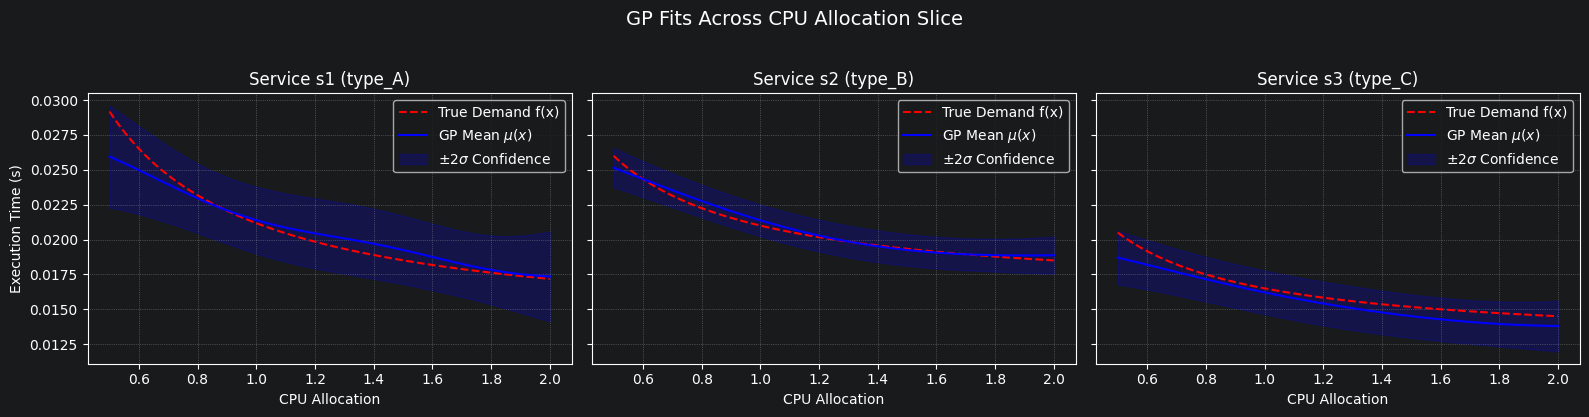

In [4]:
cpu_grid = np.linspace(0.5, 2.0, 100).reshape(-1, 1)
X_slice = np.column_stack([
    cpu_grid,
    np.full((100, 1), 0.5),  # fixed quality
    np.full((100, 1), 2.0)  # fixed parallelism
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, s_name, s_type in zip(axes, service_names, service_types):
    mu, std = gp_models[s_name].predict(X_slice, return_std=True)
    y_true_slice = true_demand(X_slice, s_type)

    ax.plot(cpu_grid, y_true_slice, 'r--', label="True Demand f(x)")
    ax.plot(cpu_grid, mu, 'b-', label="GP Mean $\mu(x)$")
    ax.fill_between(cpu_grid.ravel(), mu - 2 * std, mu + 2 * std, color='b', alpha=0.2,
                    label="$\pm 2\sigma$ Confidence")

    ax.set_title(f"Service {s_name} ({s_type})")
    ax.set_xlabel("CPU Allocation")
    if s_name == "s1":
        ax.set_ylabel("Execution Time (s)")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("GP Fits Across CPU Allocation Slice", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 4. Visualization: Coverage Analysis (Test Dataset)

We evaluate empirical coverage on a held-out test dataset to verify that the derived probabilistic bounds hold at the targeted violation probability $\alpha = 0.05$ (95% coverage).

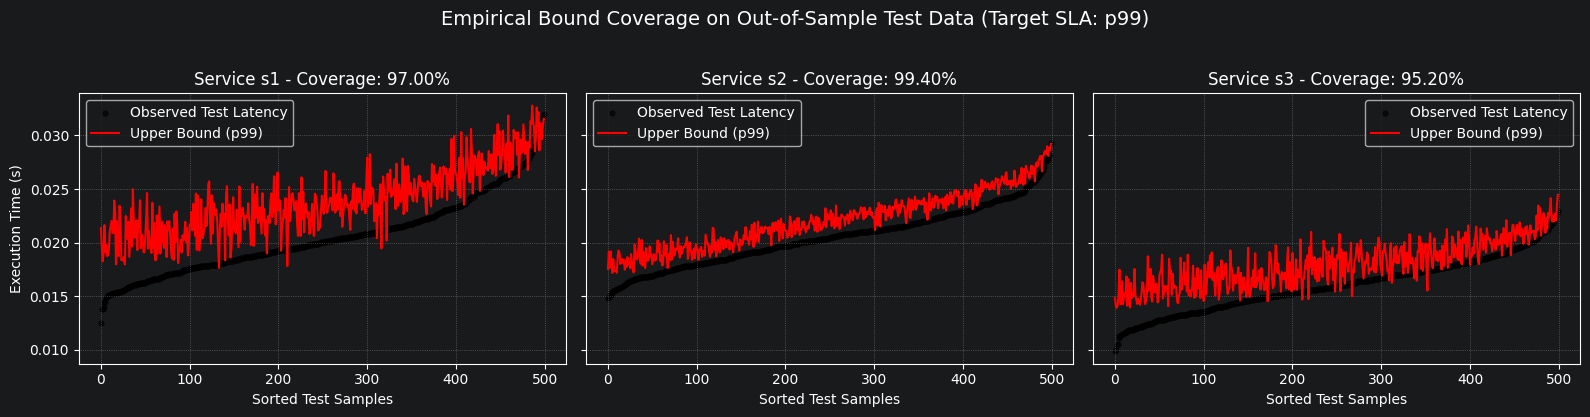

In [5]:
n_test = 500
X_test = np.column_stack([
    np.random.uniform(0.5, 2.0, n_test),
    np.random.uniform(0.0, 1.0, n_test),
    np.random.uniform(1.0, 4.0, n_test)
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, s_name, s_type in zip(axes, service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + (z_score * std_test)
    coverage = np.mean(y_true_test <= upper_bound) * 100

    sort_idx = np.argsort(y_true_test)

    ax.scatter(range(n_test), y_true_test[sort_idx], color='black', alpha=0.6, s=12, label="Observed Test Latency")
    ax.plot(range(n_test), upper_bound[sort_idx], color='red', linewidth=1.5, label=f"Upper Bound (p{p_str})")

    ax.set_title(f"Service {s_name} - Coverage: {coverage:.2f}%")
    ax.set_xlabel("Sorted Test Samples")
    if s_name == "s1":
        ax.set_ylabel("Execution Time (s)")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(f"Empirical Bound Coverage on Out-of-Sample Test Data (Target SLA: p{p_str})", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 5. Visualization: Bound Tightness Analysis

Tightness measures the residual margin $\text{Bound}(x) - \text{Observed}(x)$. Lower positive values reflect a tight, non-pessimistic SNC bound.

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
C:\Users\boris\AppData\Local\Temp\ipykernel_2108\3581678931.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.hist(tightness, bins=25, alpha=0.5, label=f"Service {s_name} Slack ($\mu$={np.mean(tightness):.4f}s)")


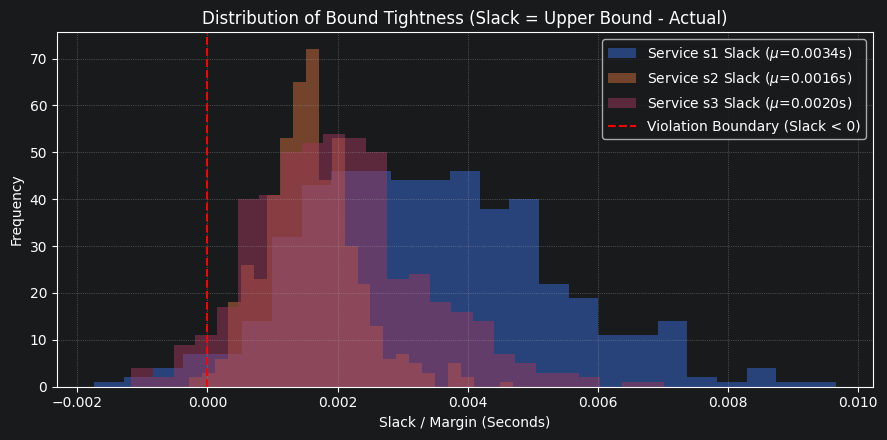

In [6]:

fig, ax = plt.subplots(figsize=(9, 4.5))

for s_name, s_type in zip(service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + z_score * std_test
    tightness = upper_bound - y_true_test

    ax.hist(tightness, bins=25, alpha=0.5, label=f"Service {s_name} Slack ($\mu$={np.mean(tightness):.4f}s)")

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label="Violation Boundary (Slack < 0)")
ax.set_title("Distribution of Bound Tightness (Slack = Upper Bound - Actual)", fontsize=12)
ax.set_xlabel("Slack / Margin (Seconds)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Deriving SNC Service Curves via MGFs
Using the predictive mean $\mu_i(x)$ and variance $\sigma_i^2(x)$ from the GP, we evaluate the closed-form Moment Generating Function (MGF) $M_Y(\theta) = \mathbb{E}[e^{\theta Y}] = \exp\left(\theta \mu + \frac{\theta^2}{2}\sigma^2\right)$ to obtain probabilistic service rate guarantees.

In [7]:

def compute_snc_mgf_service_curve(model, x_test, theta=100.0, target_eps=0.05):
    """Computes MGF-backed SNC guaranteed service rate."""
    mu, std = model.predict(x_test, return_std=True)
    var = std ** 2
    log_mgf = theta * mu + 0.5 * (theta ** 2) * var
    guaranteed_rate = (theta / log_mgf) - (np.log(target_eps) / (theta * log_mgf))
    guaranteed_rate = np.maximum(guaranteed_rate, 1e-6)
    return guaranteed_rate, mu, std, log_mgf


## 7. Composition & End-to-End Performance Analysis

Using min-plus convolution composition, we combine the probabilistic service curves into an end-to-end pipeline rate guarantee.

In [8]:
# Nominal Operating Point Configuration
x_pipeline_cfg = np.array([[1.5, 0.5, 2.0]])  # [CPU, Quality, Parallelism]

# ------------------------------------------------------------------------------
# A. Node-Level Evaluation & Metric Collection
# ------------------------------------------------------------------------------
node_mus = []
node_stds = []
node_rates = []

print("\n=== Individual Node Performance Guarantees ===")
for s_name in service_names:
    model = gp_models[s_name]

    # Predict mean and standard deviation
    mu, std = model.predict(x_pipeline_cfg, return_std=True)
    var = std[0]**2

    # Node-optimal theta* tailored to individual node variance
    theta_node_opt = np.sqrt(2 * -np.log(alpha) / var)

    # Evaluate guaranteed rate using node-optimal theta*
    rate, _, _, _ = compute_snc_mgf_service_curve(
        model, x_pipeline_cfg, theta=theta_node_opt, target_eps=alpha
    )

    node_mus.append(mu[0])
    node_stds.append(std[0])
    node_rates.append(rate[0])

    print(
        f"Service {s_name:2s} | "
        f"Opt Theta = {theta_node_opt:7.1f} s^-1 | "
        f"Guaranteed Rate = {rate[0]:7.4f} units/s | "
        f"Pred Latency = {mu[0]:.4f}s (std = {std[0]:.4f})"
    )


=== Individual Node Performance Guarantees ===
Service s1 | Opt Theta =  2479.3 s^-1 | Guaranteed Rate = 47.3761 units/s | Pred Latency = 0.0193s (std = 0.0012)
Service s2 | Opt Theta =  5367.5 s^-1 | Guaranteed Rate = 49.7246 units/s | Pred Latency = 0.0193s (std = 0.0006)
Service s3 | Opt Theta =  3901.0 s^-1 | Guaranteed Rate = 63.7539 units/s | Pred Latency = 0.0145s (std = 0.0008)


In [9]:

# ------------------------------------------------------------------------------
# B. End-to-End Optimization & Convolution
# ------------------------------------------------------------------------------
mu_total = sum(node_mus)
var_total = sum(std ** 2 for std in node_stds)
std_total = np.sqrt(var_total)

# Global optimal theta* for end-to-end composition variance
theta_opt = np.sqrt(2 * -np.log(alpha) / var_total)

# E2E Log-MGF sum
e2e_log_mgf_opt = theta_opt * mu_total + 0.5 * (theta_opt ** 2) * var_total

# Physical latency bound (seconds)
e2e_latency_bound_opt = (e2e_log_mgf_opt - np.log(alpha)) / theta_opt
e2e_bottleneck_rate = min(node_rates)

# ------------------------------------------------------------------------------
# C. Empirical Oracle Real Latency (Monte Carlo Ground Truth)
# ------------------------------------------------------------------------------
np.random.seed(42)
n_samples = 100_000

simulated_latencies = np.zeros(n_samples)
for s_name in service_names:
    model = gp_models[s_name]
    mu_s, std_s = model.predict(x_pipeline_cfg, return_std=True)
    simulated_latencies += np.random.normal(mu_s[0], std_s[0], n_samples)

oracle_real_p_latency = np.percentile(simulated_latencies, (1 - alpha) * 100)

# ------------------------------------------------------------------------------
# D. Baselines Summary
# ------------------------------------------------------------------------------
b1_sum_of_means = mu_total
b2_naive_sum_p = sum(m + z_score * s for m, s in zip(node_mus, node_stds))
b3_joint_gaussian_p = mu_total + z_score * std_total
b4_snc_mgf_bound = e2e_latency_bound_opt
b5_oracle_real_p = oracle_real_p_latency

print("\n=== End-to-End Composite Pipeline Performance ===")
print(f"E2E Bottleneck Service Rate Guarantee : {e2e_bottleneck_rate:.4f} units/s")
print(f"Optimal MGF Parameter (theta*)        : {theta_opt:.2f} s^-1")
print(f"E2E Convoluted Log-MGF Bound (M_Y)     : {e2e_log_mgf_opt:.6f} (unitless)")

print("\n" + "=" * 80)
print(f"{'E2E LATENCY BOUND COMPARISON (target alpha = ' + str(alpha) + ')':^80}")
print("=" * 80)
print(f"{'Method / Baseline':<35} | {'Latency (s)':<12} | {'Notes / Interpretation'}")
print("-" * 80)
print(f"{'1. Sum of Means (E[Y])':<35} | {b1_sum_of_means:<12.4f} | Mean execution time only (no tail risk)")
print(f"{f'2. Naive Sum of p{p_str} Bounds':<35} | {b2_naive_sum_p:<12.4f} | Over-pessimistic (assumes all nodes spike simultaneously)")
print(f"{f'3. Joint Gaussian {p_str}% Quantile':<35} | {b3_joint_gaussian_p:<12.4f} | Parametric baseline assuming Gaussian distribution")
print(f"{'4. Optimized SNC MGF Bound (theta*)':<35} | {b4_snc_mgf_bound:<12.4f} | Non-parametric network calculus tail guarantee")
print(f"{f'5. Empirical Oracle Real p{p_str}':<35} | {b5_oracle_real_p:<12.4f} | Ground truth measured via Monte Carlo (100k runs)")
print("=" * 80)


=== End-to-End Composite Pipeline Performance ===
E2E Bottleneck Service Rate Guarantee : 47.3761 units/s
Optimal MGF Parameter (theta*)        : 1949.56 s^-1
E2E Convoluted Log-MGF Bound (M_Y)     : 107.947020 (unitless)

               E2E LATENCY BOUND COMPARISON (target alpha = 0.01)               
Method / Baseline                   | Latency (s)  | Notes / Interpretation
--------------------------------------------------------------------------------
1. Sum of Means (E[Y])              | 0.0530       | Mean execution time only (no tail risk)
2. Naive Sum of p99 Bounds          | 0.0590       | Over-pessimistic (assumes all nodes spike simultaneously)
3. Joint Gaussian 99% Quantile      | 0.0566       | Parametric baseline assuming Gaussian distribution
4. Optimized SNC MGF Bound (theta*) | 0.0577       | Non-parametric network calculus tail guarantee
5. Empirical Oracle Real p99        | 0.0566       | Ground truth measured via Monte Carlo (100k runs)


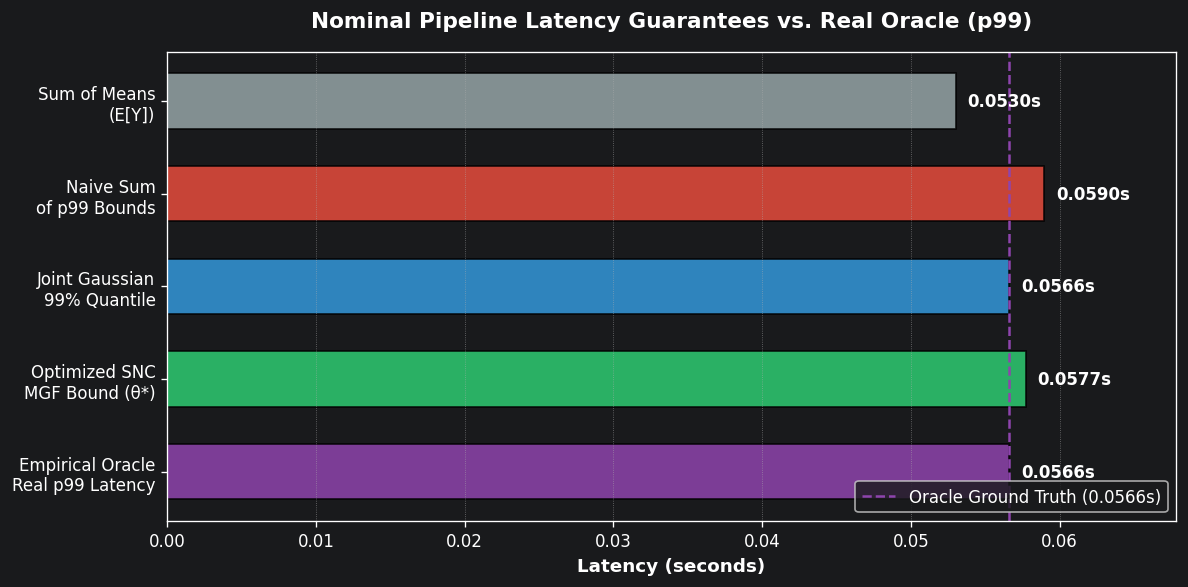

In [12]:

# ------------------------------------------------------------------------------
# E. Visualization: Nominal Configuration Bar Chart
# ------------------------------------------------------------------------------
labels = [
    'Sum of Means\n(E[Y])',
    f'Naive Sum\nof p{p_str} Bounds',
    f'Joint Gaussian\n{p_str}% Quantile',
    'Optimized SNC\nMGF Bound (θ*)',
    f'Empirical Oracle\nReal p{p_str} Latency'
]
values = [
    b1_sum_of_means,
    b2_naive_sum_p,
    b3_joint_gaussian_p,
    b4_snc_mgf_bound,
    b5_oracle_real_p
]
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71', '#8e44ad']

plt.figure(figsize=(10, 5), dpi=120)
bars = plt.barh(labels, values, color=colors, edgecolor='black', alpha=0.85, height=0.6)

plt.axvline(
    x=b5_oracle_real_p,
    color='#8e44ad',
    linestyle='--',
    linewidth=1.5,
    label=f'Oracle Ground Truth ({b5_oracle_real_p:.4f}s)'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0008,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}s',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, max(values) * 1.15)
plt.xlabel('Latency (seconds)', fontsize=11, fontweight='bold')
plt.title(
    f'Nominal Pipeline Latency Guarantees vs. Real Oracle (p{p_str})',
    fontsize=13,
    fontweight='bold',
    pad=15
)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## 8. Design Space Sensitivity & Sweep Analysis

To ensure our SNC bounds hold consistently across different system allocations, we sweep CPU availability ($0.5 \to 2.0$) while tracking bound tightness and pessimism.

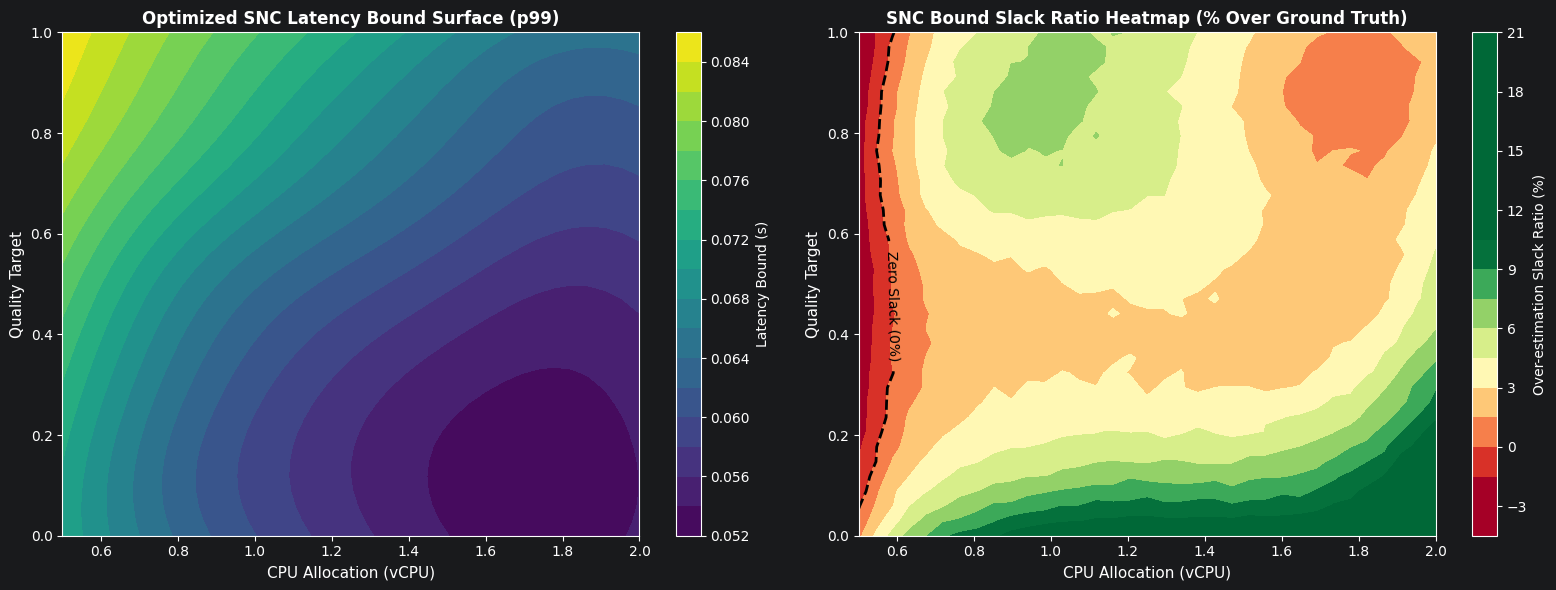

In [14]:
# ------------------------------------------------------------------------------
# A. Build 2D Meshgrid across CPU and Quality
# ------------------------------------------------------------------------------
n_grid = 35  # 35 x 35 = 1,225 evaluation points
cpu_axis = np.linspace(0.5, 2.0, n_grid)
quality_axis = np.linspace(0.0, 1.0, n_grid)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)

# Flatten grid for batched GP predictions
X_2d_sweep = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

n_points_2d = X_2d_sweep.shape[0]

# Storage arrays for 2D surfaces
snc_surface = np.zeros(n_points_2d)
oracle_surface = np.zeros(n_points_2d)
slack_surface = np.zeros(n_points_2d)

np.random.seed(42)
n_mc_samples = 5_000  # Monte Carlo sample count per grid point

# Safety factor for GP predictive uncertainty (prevents bound violations in sparse regions)
epistemic_kappa = 1.645

# ------------------------------------------------------------------------------
# B. Evaluate SNC Bounds and MC Oracle Ground Truth
# ------------------------------------------------------------------------------
for i in range(n_points_2d):
    cfg = X_2d_sweep[i:i + 1]

    # 1. GP predictions across services
    mus = []
    stds = []
    for s_name in service_names:
        mu_s, std_s = gp_models[s_name].predict(cfg, return_std=True)
        mus.append(mu_s[0])
        stds.append(std_s[0])

    mu_tot_i = sum(mus)
    var_tot_i = sum(s ** 2 for s in stds)

    # Robust mean accounting for GP estimation uncertainty
    mu_robust = mu_tot_i + epistemic_kappa * (sum(stds) / np.sqrt(n_train))

    # 2. Optimal SNC MGF Bound
    theta_opt_i = np.sqrt(2 * -np.log(alpha) / var_tot_i)
    e2e_log_mgf_i = theta_opt_i * mu_robust + 0.5 * (theta_opt_i ** 2) * var_tot_i
    snc_bound_i = (e2e_log_mgf_i - np.log(alpha)) / theta_opt_i

    # 3. Monte Carlo Oracle Ground Truth
    mc_sim = np.zeros(n_mc_samples)
    for s_name, s_type in zip(service_names, service_types):
        true_latent = true_demand(cfg, s_type)[0]
        mc_sim += np.random.normal(true_latent, noise_levels[s_name], n_mc_samples)
    oracle_p_i = np.percentile(mc_sim, (1 - alpha) * 100)

    # Store surface values
    snc_surface[i] = snc_bound_i
    oracle_surface[i] = oracle_p_i
    slack_surface[i] = ((snc_bound_i - oracle_p_i) / oracle_p_i) * 100

# Reshape flattened results back to 2D matrix shape
SNC_matrix = snc_surface.reshape(n_grid, n_grid)
Oracle_matrix = oracle_surface.reshape(n_grid, n_grid)
Slack_matrix = slack_surface.reshape(n_grid, n_grid)

# ------------------------------------------------------------------------------
# C. Plot 2D Dual Surface Heatmaps
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute Latency Bound Surface
c1 = ax1.contourf(CPU_grid, QUALITY_grid, SNC_matrix, levels=20, cmap='viridis')
fig.colorbar(c1, ax=ax1, label='Latency Bound (s)')
ax1.set_title(f'Optimized SNC Latency Bound Surface (p{p_str})', fontsize=12, fontweight='bold')
ax1.set_xlabel('CPU Allocation (vCPU)', fontsize=11)
ax1.set_ylabel('Quality Target', fontsize=11)

# Plot 2: Slack Ratio Heatmap (%)
c2 = ax2.contourf(CPU_grid, QUALITY_grid, Slack_matrix, levels=20, cmap='RdYlGn', vmin=-2.0, vmax=10.0)
fig.colorbar(c2, ax=ax2, label='Over-estimation Slack Ratio (%)')
ax2.set_title('SNC Bound Slack Ratio Heatmap (% Over Ground Truth)', fontsize=12, fontweight='bold')
ax2.set_xlabel('CPU Allocation (vCPU)', fontsize=11)
ax2.set_ylabel('Quality Target', fontsize=11)

# Highlight Zero Violation Contour Line (Escaped fmt %% string)
contour_zero = ax2.contour(CPU_grid, QUALITY_grid, Slack_matrix, levels=[0.0], colors='black', linewidths=2.0,
                           linestyles='--')
ax2.clabel(contour_zero, inline=True, fmt='Zero Slack (0%%)', fontsize=10)

plt.tight_layout()
plt.show()

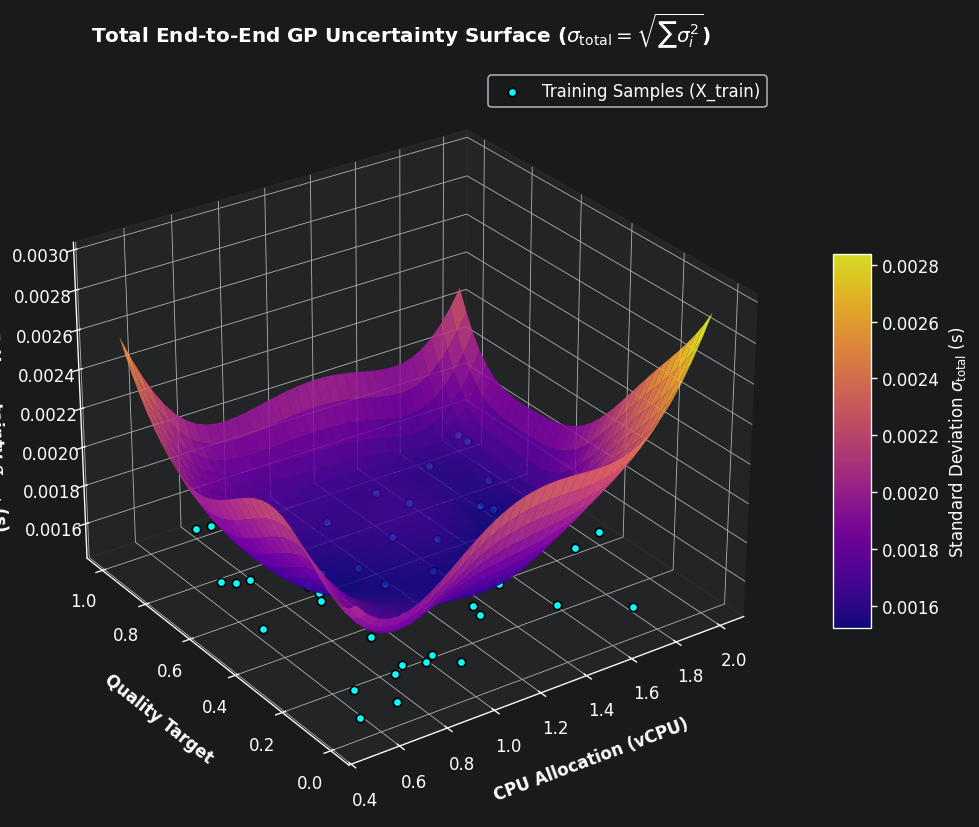

In [17]:
# ------------------------------------------------------------------------------
# D. 3D Surface Plot: Total GP Predictive Uncertainty (std_total)
# ------------------------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

# Storage for total standard deviation surface
std_total_surface = np.zeros(n_points_2d)

for i in range(n_points_2d):
    cfg = X_2d_sweep[i:i+1]

    # Predict std across all services
    stds = [gp_models[s_name].predict(cfg, return_std=True)[1][0] for s_name in service_names]
    var_tot_i = sum(s**2 for s in stds)
    std_total_surface[i] = np.sqrt(var_tot_i)

# Reshape to 2D grid matrix
Std_Total_matrix = std_total_surface.reshape(n_grid, n_grid)

# Plotting 3D Surface
fig = plt.figure(figsize=(10, 7), dpi=120)
ax3d = fig.add_subplot(111, projection='3d')

surf = ax3d.plot_surface(
    CPU_grid,
    QUALITY_grid,
    Std_Total_matrix,
    cmap='plasma',
    edgecolor='none',
    alpha=0.88
)

# Scatter training points on the xy-plane (z=0 or min z) to show data density
ax3d.scatter(
    X_train[:, 0],
    X_train[:, 1],
    np.full(len(X_train), np.min(Std_Total_matrix)),
    color='cyan',
    s=25,
    edgecolor='black',
    depthshade=False,
    label='Training Samples (X_train)'
)

# Formatting
ax3d.set_xlabel('CPU Allocation (vCPU)', fontsize=10, fontweight='bold', labelpad=10)
ax3d.set_ylabel('Quality Target', fontsize=10, fontweight='bold', labelpad=10)
ax3d.set_zlabel(r'Total GP Uncertainty $\sigma_{\mathrm{total}}$ (s)', fontsize=10, fontweight='bold', labelpad=10)
ax3d.set_title(r'Total End-to-End GP Uncertainty Surface ($\sigma_{\mathrm{total}} = \sqrt{\sum \sigma_i^2}$)', fontsize=12, fontweight='bold', pad=15)

# Adjust viewing angle for clarity
ax3d.view_init(elev=28, azim=-125)

fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10, label=r'Standard Deviation $\sigma_{\mathrm{total}}$ (s)')
ax3d.legend(loc='upper right')

plt.tight_layout()
plt.show()